# Phase 3: Cleaning and Feature Transformation

**Project:** CogniLend – Loan Approval Decision-Support System
**Input:** `data/raw/loan_applications_raw.csv` + decisions from the Phase 1 and Phase 2 reports (issue IDs P01–P24)
**Outputs:**

| File | What it is | Who uses it |
|---|---|---|
| `data/processed/semi_preprocessed_dataset.csv` | **Main deliverable.** Clean, filled, outliers treated, transformed, encoded and scaled | Phase 4 (model features) |
| `data/processed/cleaned_dataset_original_units.csv` | Clean and filled, but still in **real units** (₹, years, CIBIL points) and readable labels | Phase 4 (to build ratios like FOIR), rule engine, audit log |
| `phase3/transform_params.json` | Every value we used (medians, caps, scaler mean/std, encodings) | Phase 4, and to turn scaled values back into ₹ for explanations |

**Tasks in this phase:** duplicates, data-type fixes, missing-value imputation, outlier treatment, transforms, encoding, scaling.
**Not in this phase:** building new features (FOIR, loan-to-income, ...), feature selection, PCA. These are Phase 4.

**Why two cleaned files?** Phase 4 must build ratios such as FOIR from **real rupee values**. If it used capped or scaled numbers,
the ratios would be wrong (for example, a capped income would make FOIR look too high). So we keep one file in real units and one model-ready file.

**Note on fitting:** medians, caps and the scaler are calculated on all 9,847 cleaned rows, so the pipeline gives the agreed final dataset.
When the model is trained later, the same steps must be **fitted on the training split only** and then applied to the test split (to avoid data leakage).

## Step 0: Import libraries and set paths

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

MAIN_COLOR = '#2a78d6'      # blue   -> after / clean
SECOND_COLOR = '#eb6834'    # orange -> before / problem
MISSING_COLOR = '#b5b5b5'   # grey

sns.set_style('whitegrid')
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['grid.color'] = '#e6e6e6'
plt.rcParams['axes.edgecolor'] = '#999999'

RAW_PATH = '../data/raw/loan_applications_raw.csv'
OUT_DIR = '../data/processed'
PLOT_DIR = 'plots'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)


def save_plot(file_name):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


# every step writes one line here, so we get a full cleaning log at the end
cleaning_log = []


def add_log(issue_id, step, count, rows_now):
    cleaning_log.append({'issue': issue_id, 'step': step, 'count': count, 'rows_after_step': rows_now})
    print(step, '->', count, '| rows now:', rows_now)

In [2]:
raw = pd.read_csv(RAW_PATH)
df = raw.copy()          # working copy (raw is kept only for before/after plots)
print('Raw data:', raw.shape)

Raw data: (10000, 17)


## Part A: Cleaning

Each step names the issue ID from the Phase 1/2 reports that it closes.

### A1. Remove extra spaces from text columns (P03)

In [3]:
text_cols = df.select_dtypes(exclude='number').columns
cells_with_space = 0
for col in text_cols:
    values = df[col]
    has_space = values.notnull() & (values != values.str.strip())
    cells_with_space = cells_with_space + has_space.sum()
    df[col] = values.str.strip()

add_log('P03', 'Extra spaces removed (cells)', cells_with_space, len(df))

Extra spaces removed (cells) -> 991 | rows now: 10000


### A2. Remove exact duplicate rows (P01)

In [4]:
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
add_log('P01', 'Exact duplicate rows removed', n_duplicates, len(df))
print('Loan_ID repeated after this step:', df['Loan_ID'].duplicated().sum())

Exact duplicate rows removed -> 135 | rows now: 9865
Loan_ID repeated after this step: 0


### A3. Drop rows with no target (P02)

We never guess the target, because it is what the model must learn.

In [5]:
n_no_target = df['Loan_Status'].isnull().sum()
df = df[df['Loan_Status'].notnull()].reset_index(drop=True)
add_log('P02', 'Rows without Loan_Status removed', n_no_target, len(df))

Rows without Loan_Status removed -> 18 | rows now: 9847


### A4. Standardise category labels (P03)
The map is the `plot_map` from Phase 1/2, now used for real. Short names: **SEP** = Self-Employed Professional, **SENP** = Self-Employed Non-Professional.

In [6]:
clean_map = {
    'Gender': {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female',
               'transgender': 'Transgender', 'tg': 'Transgender'},
    'Marital_Status': {'married': 'Married', 'single': 'Single', 'unmarried': 'Single',
                       'divorced': 'Divorced', 'widowed': 'Widowed'},
    'Employment_Type': {'salaried': 'Salaried', 'service': 'Salaried',
                        'self-employed professional': 'SEP', 'self employed professional': 'SEP', 'sep': 'SEP',
                        'self-employed non-professional': 'SENP', 'self employed business': 'SENP',
                        'business owner': 'SENP', 'senp': 'SENP'},
    'Loan_Type': {'home loan': 'Home', 'housing loan': 'Home', 'hl': 'Home',
                  'vehicle loan': 'Vehicle', 'auto loan': 'Vehicle', 'car loan': 'Vehicle',
                  'personal loan': 'Personal', 'personal': 'Personal', 'pl': 'Personal',
                  'business loan': 'Business', 'msme loan': 'Business', 'bl': 'Business'},
    'Property_Area': {'urban': 'Urban', 'semi-urban': 'Semi-Urban', 'semi urban': 'Semi-Urban',
                      'semiurban': 'Semi-Urban', 'rural': 'Rural'},
}

# correct full spellings from Phase 1 (used only to count the badly spelled cells)
phase1_correct = {
    'Gender': ['Male', 'Female', 'Transgender'],
    'Marital_Status': ['Married', 'Single', 'Divorced', 'Widowed'],
    'Employment_Type': ['Salaried', 'Self-Employed Professional', 'Self-Employed Non-Professional'],
    'Loan_Type': ['Home Loan', 'Vehicle Loan', 'Personal Loan', 'Business Loan'],
    'Property_Area': ['Urban', 'Semi-Urban', 'Rural'],
}

total_bad = 0
for col in clean_map:
    before = df[col].copy()
    spellings_before = before.nunique()
    badly_spelled = (before.notnull() & ~before.isin(phase1_correct[col])).sum()
    df[col] = before.str.lower().map(clean_map[col])

    not_mapped = df[col].isnull().sum() - before.isnull().sum()
    total_bad = total_bad + badly_spelled
    print(col, ': spellings', spellings_before, '->', df[col].nunique(),
          '| badly spelled cells fixed:', badly_spelled, '| not mapped:', not_mapped)

add_log('P03', 'Badly spelled category cells fixed', total_bad, len(df))
print()
print('Clean labels:', sorted(df['Employment_Type'].unique()), sorted(df['Loan_Type'].unique()))

Gender : spellings 11 -> 3 | badly spelled cells fixed: 775 | not mapped: 0
Marital_Status : spellings 10 -> 4 | badly spelled cells fixed: 776 | not mapped: 0
Employment_Type : spellings 12 -> 3 | badly spelled cells fixed: 788 | not mapped: 0
Loan_Type : spellings 16 -> 4 | badly spelled cells fixed: 788 | not mapped: 0
Property_Area : spellings 10 -> 3 | badly spelled cells fixed: 777 | not mapped: 0
Badly spelled category cells fixed -> 3904 | rows now: 9847

Clean labels: ['SENP', 'SEP', 'Salaried'] ['Business', 'Home', 'Personal', 'Vehicle']


### A5. Fix data types (P04, P05)

In [7]:
print('Types before:')
print(df.dtypes[['Loan_Amount', 'Dependents', 'Loan_Status']])

# Loan_Amount: remove "Rs." and commas, then convert to a number
text_amounts = df['Loan_Amount'].str.contains(',', na=False).sum()
amount = df['Loan_Amount'].str.replace('Rs.', '', regex=False)
amount = amount.str.replace(',', '', regex=False).str.strip()
df['Loan_Amount'] = pd.to_numeric(amount)
add_log('P04', 'Loan_Amount text values converted to numbers', text_amounts, len(df))

# Dependents: "3+" -> 3
n_3plus = (df['Dependents'] == '3+').sum()
df['Dependents'] = pd.to_numeric(df['Dependents'].str.replace('+', '', regex=False))
add_log('P05', 'Dependents "3+" changed to 3', n_3plus, len(df))

# Target: Approved = 1, Rejected = 0
df['Loan_Status'] = (df['Loan_Status'] == 'Approved').astype(int)

print()
print('Types after:')
print(df.dtypes[['Loan_Amount', 'Dependents', 'Loan_Status']])

Types before:
Loan_Amount    str
Dependents     str
Loan_Status    str
dtype: object
Loan_Amount text values converted to numbers -> 578 | rows now: 9847
Dependents "3+" changed to 3 -> 1819 | rows now: 9847

Types after:
Loan_Amount    float64
Dependents     float64
Loan_Status      int64
dtype: object


### A6. Fix invalid values (P07–P11, P13, P19)
If the correct value is **clear**, we fix it. If not, we turn it into a missing value and fill it in Part B.

In [8]:
# P07: impossible age -> missing
bad_age = (df['Age'] < 18) | (df['Age'] > 75)
df.loc[bad_age, 'Age'] = np.nan
add_log('P07', 'Impossible Age set to missing', bad_age.sum(), len(df))

# P09: negative income is a sign error -> remove the minus sign
negative_income = df['Monthly_Income'] < 0
df.loc[negative_income, 'Monthly_Income'] = df.loc[negative_income, 'Monthly_Income'] * -1
add_log('P09', 'Negative Monthly_Income made positive', negative_income.sum(), len(df))

# P10: zero income -> missing
zero_income = df['Monthly_Income'] == 0
df.loc[zero_income, 'Monthly_Income'] = np.nan
add_log('P10', 'Zero Monthly_Income set to missing', zero_income.sum(), len(df))

# P11: CIBIL outside 300-900 (but -1 is a valid code) -> missing
bad_cibil = (df['CIBIL_Score'] != -1) & ((df['CIBIL_Score'] < 300) | (df['CIBIL_Score'] > 900))
df.loc[bad_cibil, 'CIBIL_Score'] = np.nan
add_log('P11', 'Invalid CIBIL_Score set to missing', bad_cibil.sum(), len(df))

# P08 + P19: experience below 0, above 50, or more than (age - 18) -> missing
bad_exp = (df['Work_Experience'] < 0) | (df['Work_Experience'] > 50) | (df['Work_Experience'] > df['Age'] - 18)
df.loc[bad_exp, 'Work_Experience'] = np.nan
add_log('P08+P19', 'Invalid Work_Experience set to missing', bad_exp.sum(), len(df))

# P13: home-loan tenure typed in years -> multiply by 12
years_typed = (df['Loan_Type'] == 'Home') & (df['Loan_Tenure'] <= 30)
df.loc[years_typed, 'Loan_Tenure'] = df.loc[years_typed, 'Loan_Tenure'] * 12
add_log('P13', 'Home-loan tenure changed from years to months', years_typed.sum(), len(df))

Impossible Age set to missing -> 28 | rows now: 9847
Negative Monthly_Income made positive -> 22 | rows now: 9847
Zero Monthly_Income set to missing -> 8 | rows now: 9847
Invalid CIBIL_Score set to missing -> 32 | rows now: 9847
Invalid Work_Experience set to missing -> 45 | rows now: 9847
Home-loan tenure changed from years to months -> 95 | rows now: 9847


**Result of Part A (cleaning):**

| Step | Issue | Count |
|---|---|---|
| Extra spaces removed | P03 | 991 cells |
| Duplicate rows removed | P01 | 135 rows (10,000 → 9,865) |
| Rows without target removed | P02 | 18 rows (9,865 → 9,847) |
| Badly spelled labels fixed | P03 | 3,904 cells (Gender 775, Marital 776, Employment 788, Loan_Type 788, Area 777) |
| Loan_Amount text → number | P04 | 578 |
| Dependents "3+" → 3 | P05 | 1,819 |
| Impossible Age → missing | P07 | 28 |
| Negative income → positive | P09 | 22 |
| Zero income → missing | P10 | 8 |
| Invalid CIBIL → missing | P11 | 32 |
| Invalid Work_Experience → missing | P08 + P19 | 45 |
| Home-loan tenure years → months (×12) | P13 | 95 |

Some counts are a little lower than in Phase 1 (for example 578 instead of 584) because the duplicate rows were removed first.
The clean labels are short: Employment_Type = Salaried / SEP / SENP, Loan_Type = Home / Vehicle / Personal / Business.

## Part B: Missing-value imputation

### B1. Missing values before filling

In [9]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print('Total missing cells:', missing_before.sum())
missing_before

Total missing cells: 12724


Coapplicant_Income    6685
Collateral_Value      4181
Work_Experience        341
Existing_EMI           247
Dependents             236
Loan_Tenure            178
Gender                 176
Loan_Amount            148
Property_Area          148
CIBIL_Score            131
Marital_Status         118
Monthly_Income         107
Age                     28
dtype: int64

### B2. How each column is filled (decided from Phase 1 and Phase 2)

| Column | Type of missing | How we fill it | Evidence |
|---|---|---|---|
| Coapplicant_Income | Structural (no co-applicant) | **0** | Phase 2 A1, P14 |
| Collateral_Value (Personal, Business) | Structural (unsecured) | **0** | Phase 2 A2, P15 |
| Gender, Marital_Status | Protected attribute | **"Unknown"** (never guessed) | Phase 1 Section 7 |
| Property_Area | Random | Mode | Phase 2 A7 |
| Dependents | Random | Mode inside each Marital_Status group | Married people have more dependents |
| Age | Random + invalid | Median inside each Employment_Type | Age differs by job type |
| Monthly_Income | Random + invalid | Median inside Employment_Type × Property_Area | Income depends on both (Phase 2 C2) |
| Work_Experience | Random + invalid | Median inside Employment_Type, then limited to [0, Age − 18] | Keeps it possible for the age |
| Existing_EMI | Random | Median (= 0) | Most people have no existing loan |
| CIBIL_Score | Random + invalid | Median of scored applicants | −1 rows are **not** missing and are kept |
| Loan_Amount | Random | Median inside each Loan_Type | Loan sizes differ a lot by type |
| Loan_Tenure | Random | Mode inside each Loan_Type | Tenure options differ by type |
| Collateral_Value (Home, Vehicle) | Really missing (P20) | Loan_Amount ÷ median LTV of that loan type | Collateral follows the loan amount (Phase 2: 0.98) |

We fill in this order because some steps use columns filled earlier (for example, income uses Property_Area).

In [10]:
imputation_values = {}   # saved later in transform_params.json


def get_mode(values):
    return values.mode()[0]


# structural blanks
n = df['Coapplicant_Income'].isnull().sum()
df['Coapplicant_Income'] = df['Coapplicant_Income'].fillna(0)
add_log('P14', 'Coapplicant_Income blank -> 0', n, len(df))

unsecured_blank = df['Loan_Type'].isin(['Personal', 'Business']) & df['Collateral_Value'].isnull()
df.loc[unsecured_blank, 'Collateral_Value'] = 0
add_log('P15', 'Collateral_Value blank on Personal/Business -> 0', unsecured_blank.sum(), len(df))

# protected attributes
for col in ['Gender', 'Marital_Status']:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna('Unknown')
    add_log('P16', col + ' missing -> "Unknown"', n, len(df))

Coapplicant_Income blank -> 0 -> 6685 | rows now: 9847
Collateral_Value blank on Personal/Business -> 0 -> 3976 | rows now: 9847
Gender missing -> "Unknown" -> 176 | rows now: 9847
Marital_Status missing -> "Unknown" -> 118 | rows now: 9847


In [11]:
# categorical
n = df['Property_Area'].isnull().sum()
area_mode = df['Property_Area'].mode()[0]
df['Property_Area'] = df['Property_Area'].fillna(area_mode)
imputation_values['Property_Area'] = area_mode
add_log('P16', 'Property_Area missing -> mode (' + area_mode + ')', n, len(df))

n = df['Dependents'].isnull().sum()
dependents_mode = df.groupby('Marital_Status')['Dependents'].agg(get_mode)
df['Dependents'] = df['Dependents'].fillna(df['Marital_Status'].map(dependents_mode))
imputation_values['Dependents_by_Marital_Status'] = dependents_mode.to_dict()
add_log('P16', 'Dependents missing -> mode per Marital_Status', n, len(df))
print(dependents_mode)

Property_Area missing -> mode (Urban) -> 148 | rows now: 9847
Dependents missing -> mode per Marital_Status -> 236 | rows now: 9847
Marital_Status
Divorced    0.0
Married     2.0
Single      0.0
Unknown     0.0
Widowed     0.0
Name: Dependents, dtype: float64


In [12]:
# numeric: group medians
n = df['Age'].isnull().sum()
age_median = df.groupby('Employment_Type')['Age'].median()
df['Age'] = df['Age'].fillna(df.groupby('Employment_Type')['Age'].transform('median'))
imputation_values['Age_by_Employment_Type'] = age_median.to_dict()
add_log('P07+P16', 'Age missing -> median per Employment_Type', n, len(df))

n = df['Monthly_Income'].isnull().sum()
df['Monthly_Income'] = df['Monthly_Income'].fillna(
    df.groupby(['Employment_Type', 'Property_Area'])['Monthly_Income'].transform('median'))
add_log('P10+P16', 'Monthly_Income missing -> median per Employment_Type x Property_Area', n, len(df))

n = df['Work_Experience'].isnull().sum()
exp_median = df.groupby('Employment_Type')['Work_Experience'].median()
df['Work_Experience'] = df['Work_Experience'].fillna(df.groupby('Employment_Type')['Work_Experience'].transform('median'))
df['Work_Experience'] = df['Work_Experience'].clip(0, df['Age'] - 18)     # experience must fit the age
imputation_values['Work_Experience_by_Employment_Type'] = exp_median.to_dict()
add_log('P08+P16', 'Work_Experience missing -> median per Employment_Type (then limited to Age - 18)', n, len(df))

n = df['Existing_EMI'].isnull().sum()
emi_median = df['Existing_EMI'].median()
df['Existing_EMI'] = df['Existing_EMI'].fillna(emi_median)
imputation_values['Existing_EMI'] = emi_median
add_log('P16', 'Existing_EMI missing -> median (' + str(emi_median) + ')', n, len(df))

n = df['CIBIL_Score'].isnull().sum()
cibil_median = df.loc[df['CIBIL_Score'] >= 300, 'CIBIL_Score'].median()     # -1 rows are not used here
df['CIBIL_Score'] = df['CIBIL_Score'].fillna(cibil_median)
imputation_values['CIBIL_Score'] = cibil_median
add_log('P11+P16', 'CIBIL_Score missing -> median of scored applicants (' + str(cibil_median) + ')', n, len(df))

n = df['Loan_Amount'].isnull().sum()
amount_median = df.groupby('Loan_Type')['Loan_Amount'].median()
df['Loan_Amount'] = df['Loan_Amount'].fillna(df.groupby('Loan_Type')['Loan_Amount'].transform('median'))
imputation_values['Loan_Amount_by_Loan_Type'] = amount_median.to_dict()
add_log('P16', 'Loan_Amount missing -> median per Loan_Type', n, len(df))

n = df['Loan_Tenure'].isnull().sum()
tenure_mode = df.groupby('Loan_Type')['Loan_Tenure'].agg(get_mode)
df['Loan_Tenure'] = df['Loan_Tenure'].fillna(df['Loan_Type'].map(tenure_mode))
imputation_values['Loan_Tenure_by_Loan_Type'] = tenure_mode.to_dict()
add_log('P16', 'Loan_Tenure missing -> mode per Loan_Type', n, len(df))
print(tenure_mode)

Age missing -> median per Employment_Type -> 28 | rows now: 9847
Monthly_Income missing -> median per Employment_Type x Property_Area -> 107 | rows now: 9847
Work_Experience missing -> median per Employment_Type (then limited to Age - 18) -> 341 | rows now: 9847
Existing_EMI missing -> median (0.0) -> 247 | rows now: 9847
CIBIL_Score missing -> median of scored applicants (739.0) -> 131 | rows now: 9847
Loan_Amount missing -> median per Loan_Type -> 148 | rows now: 9847
Loan_Tenure missing -> mode per Loan_Type -> 178 | rows now: 9847
Loan_Type
Business     36.0
Home        240.0
Personal     36.0
Vehicle      60.0
Name: Loan_Tenure, dtype: float64


In [13]:
# P20: Home / Vehicle loans always have collateral -> estimate it from the loan amount
secured = df['Collateral_Value'] > 0
ltv = df.loc[secured, 'Loan_Amount'] / df.loc[secured, 'Collateral_Value']
median_ltv = ltv.groupby(df.loc[secured, 'Loan_Type']).median()
print('Median loan-to-value of secured loans:')
print(median_ltv.round(3))

still_missing = df['Collateral_Value'].isnull()
print()
print('Collateral still missing by type:')
print(df.loc[still_missing, 'Loan_Type'].value_counts())

estimate = df.loc[still_missing, 'Loan_Amount'] / df.loc[still_missing, 'Loan_Type'].map(median_ltv)
df.loc[still_missing, 'Collateral_Value'] = estimate.round(-4)      # round to the nearest Rs. 10,000
imputation_values['Median_LTV_by_Loan_Type'] = median_ltv[['Home', 'Vehicle']].to_dict()
add_log('P20', 'Collateral_Value missing on Home/Vehicle -> Loan_Amount / median LTV', still_missing.sum(), len(df))

Median loan-to-value of secured loans:
Loan_Type
Business    0.555
Home        0.672
Vehicle     0.851
dtype: float64

Collateral still missing by type:
Loan_Type
Home       119
Vehicle     86
Name: count, dtype: int64
Collateral_Value missing on Home/Vehicle -> Loan_Amount / median LTV -> 205 | rows now: 9847


### B3. Whole numbers back to integers (P06) and final check

In [14]:
for col in ['Age', 'Dependents', 'Work_Experience', 'CIBIL_Score', 'Loan_Tenure']:
    df[col] = df[col].round().astype(int)

print('Missing values left:', df.isnull().sum().sum())
print('Shape:', df.shape)
print()
print(df.dtypes)

Missing values left: 0
Shape: (9847, 17)

Loan_ID                   str
Age                     int64
Gender                    str
Marital_Status            str
Dependents              int64
Employment_Type           str
Work_Experience         int64
Monthly_Income        float64
Coapplicant_Income    float64
Existing_EMI          float64
CIBIL_Score             int64
Loan_Type                 str
Loan_Amount           float64
Loan_Tenure             int64
Collateral_Value      float64
Property_Area             str
Loan_Status             int64
dtype: object


### B4. Did filling change the shape of the data? (before vs after)

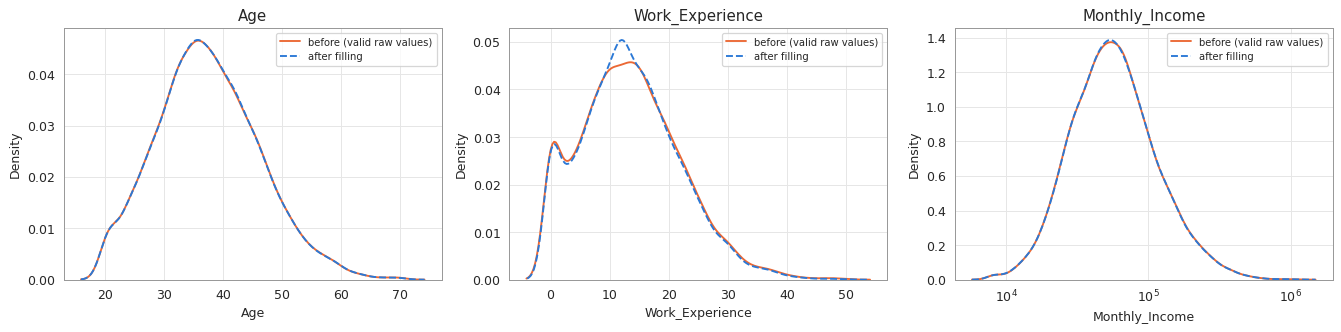

Age -> median before (valid raw): 37.0 | median after filling: 37.0
Work_Experience -> median before (valid raw): 13.0 | median after filling: 13.0
Monthly_Income -> median before (valid raw): 55300.0 | median after filling: 55100.0


In [15]:
check_cols = ['Age', 'Work_Experience', 'Monthly_Income']
valid_limits = {'Age': (18, 75), 'Work_Experience': (0, 50), 'Monthly_Income': (1, 2000000)}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for i, col in enumerate(check_cols):
    low = valid_limits[col][0]
    high = valid_limits[col][1]
    before = raw[col][(raw[col] >= low) & (raw[col] <= high)]          # valid raw values only
    log_x = (col == 'Monthly_Income')
    sns.kdeplot(before, ax=axes[i], color=SECOND_COLOR, label='before (valid raw values)', log_scale=log_x)
    sns.kdeplot(df[col], ax=axes[i], color=MAIN_COLOR, linestyle='--', label='after filling', log_scale=log_x)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
save_plot('p3_imputation_check.png')

for col in check_cols:
    low = valid_limits[col][0]
    high = valid_limits[col][1]
    before = raw[col][(raw[col] >= low) & (raw[col] <= high)]
    print(col, '-> median before (valid raw):', before.median(), '| median after filling:', df[col].median())

**Result of Part B (missing values):**
- **12,724 missing cells before filling → 0 after.**
- Structural blanks: Coapplicant_Income 6,685 → 0, Collateral_Value on Personal/Business 3,976 → 0.
- Collateral really missing on Home (119) and Vehicle (86) loans: **205 rows** were estimated as Loan_Amount ÷ median LTV (Home 0.672, Vehicle 0.851). Phase 2 counted 209 because duplicates were still inside.
- Group values used: Dependents mode = 2 for Married and 0 for the others. Tenure mode = Home 240, Vehicle 60, Personal 36, Business 36 months. Existing_EMI median = 0. CIBIL median = 739.
- **The shape did not change.** The before/after curves lie on top of each other. Medians: Age 37 → 37, Work_Experience 13 → 13, Monthly_Income ₹55,300 → ₹55,100.
  Work_Experience has a small bump at its median because 341 values were filled there (3.5% of rows).

### B5. Save the cleaned dataset in real units
This is the **clean, readable** version: real ₹ values, years and CIBIL points, with text labels. CIBIL −1 (no credit history) is kept as −1.
Phase 4 builds its ratios from this file, and the rule engine checks bank rules on it.

In [16]:
clean_df = df.copy()
clean_path = os.path.join(OUT_DIR, 'cleaned_dataset_original_units.csv')
clean_df.to_csv(clean_path, index=False)
print('Saved:', clean_path, clean_df.shape)
clean_df.head()

Saved: ../data/processed/cleaned_dataset_original_units.csv (9847, 17)


,Loan_ID,Age,Gender,Marital_Status,Dependents,Employment_Type,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Amount,Loan_Tenure,Collateral_Value,Property_Area,Loan_Status
0,LN2025102971,40,Transgender,Married,0,Salaried,18,45800.0,0.0,1900.0,821,Home,1440000.0,240,2080000.0,Rural,1
1,LN2025107793,46,Male,Married,2,SENP,19,38400.0,0.0,0.0,748,Personal,280000.0,36,0.0,Semi-Urban,1
2,LN2025102488,24,Male,Single,0,Salaried,4,39400.0,23600.0,0.0,851,Home,2690000.0,240,3710000.0,Rural,1
3,LN2025106297,34,Male,Married,0,SENP,10,51000.0,0.0,0.0,747,Home,2180000.0,240,2940000.0,Urban,1
4,LN2025108470,23,Male,Single,0,Salaried,0,43500.0,0.0,0.0,801,Personal,460000.0,36,0.0,Semi-Urban,0


## Part C: Transformation for the model

From here we work on a **copy** (`model_df`). `clean_df` stays in real units.

### C1. CIBIL −1 (no credit history) (P12)
Phase 2 showed that −1 is its own group (41.7% approval). It is **not** a very low score.
We keep its meaning in a 0/1 column `is_new_to_credit`, then replace −1 with the median score (739) so the score column stays a normal scale.

In [17]:
model_df = clean_df.copy()

model_df['is_new_to_credit'] = (model_df['CIBIL_Score'] == -1).astype(int)
n_ntc = model_df['is_new_to_credit'].sum()
model_df['CIBIL_Score'] = model_df['CIBIL_Score'].replace(-1, int(cibil_median))
add_log('P12', 'CIBIL -1 -> flag is_new_to_credit + score set to median ' + str(int(cibil_median)), n_ntc, len(model_df))
print('CIBIL range now:', model_df['CIBIL_Score'].min(), 'to', model_df['CIBIL_Score'].max())

CIBIL -1 -> flag is_new_to_credit + score set to median 739 -> 598 | rows now: 9847
CIBIL range now: 436 to 900


### C2. Outlier treatment (P17)

**Our decision for each numeric column:**

| Column(s) | IQR outliers are... | Treatment |
|---|---|---|
| Monthly_Income, Coapplicant_Income, Existing_EMI, Loan_Amount, Collateral_Value | Real but extreme money values (rich applicants, big home loans) | **Cap at the 1st and 99th percentile** (winsorizing). Rows are kept |
| Age, Work_Experience, CIBIL_Score | Real and mild (older applicants, weak borrowers) | Keep |
| Loan_Tenure | 300 and 360 months are normal home-loan tenures | Keep |
| Dependents | Only 0–3 | Keep |

**We do not delete any row**, because the outliers are real customers (Phase 2 A6). The invalid values were already fixed in A6.
The capping is done only on `model_df`; `clean_df` keeps the real values.

In [18]:
numeric_cols = ['Age', 'Dependents', 'Work_Experience', 'Monthly_Income', 'Coapplicant_Income',
                'Existing_EMI', 'CIBIL_Score', 'Loan_Amount', 'Loan_Tenure', 'Collateral_Value']

outlier_table = []
for col in numeric_cols:
    values = model_df[col]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    n_out = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()
    outlier_table.append({'column': col, 'iqr_outliers': n_out, 'percent': round(n_out / len(values) * 100, 2)})
pd.DataFrame(outlier_table)

,column,iqr_outliers,percent
0,Age,62,0.63
1,Dependents,0,0.00
2,Work_Experience,61,0.62
3,Monthly_Income,683,6.94
4,Coapplicant_Income,671,6.81
5,Existing_EMI,1144,11.62
6,CIBIL_Score,234,2.38
7,Loan_Amount,841,8.54
8,Loan_Tenure,558,5.67
9,Collateral_Value,988,10.03


In [19]:
money_cols = ['Monthly_Income', 'Coapplicant_Income', 'Existing_EMI', 'Loan_Amount', 'Collateral_Value']
cap_values = {}
before_capping = model_df[money_cols].copy()

for col in money_cols:
    low = model_df[col].quantile(0.01)
    high = model_df[col].quantile(0.99)
    n_capped = ((model_df[col] < low) | (model_df[col] > high)).sum()
    model_df[col] = model_df[col].clip(low, high)
    cap_values[col] = [float(low), float(high)]
    print(col, '-> capped to [', round(low), ',', round(high), '] | values changed:', n_capped)
    add_log('P17', col + ' capped at 1st/99th percentile', n_capped, len(model_df))

Monthly_Income -> capped to [ 12700 , 333480 ] | values changed: 192
Monthly_Income capped at 1st/99th percentile -> 192 | rows now: 9847
Coapplicant_Income -> capped to [ 0 , 103800 ] | values changed: 98
Coapplicant_Income capped at 1st/99th percentile -> 98 | rows now: 9847
Existing_EMI -> capped to [ 0 , 59800 ] | values changed: 98
Existing_EMI capped at 1st/99th percentile -> 98 | rows now: 9847
Loan_Amount -> capped to [ 60000 , 10479400 ] | values changed: 164
Loan_Amount capped at 1st/99th percentile -> 164 | rows now: 9847
Collateral_Value -> capped to [ 0 , 16910200 ] | values changed: 99
Collateral_Value capped at 1st/99th percentile -> 99 | rows now: 9847


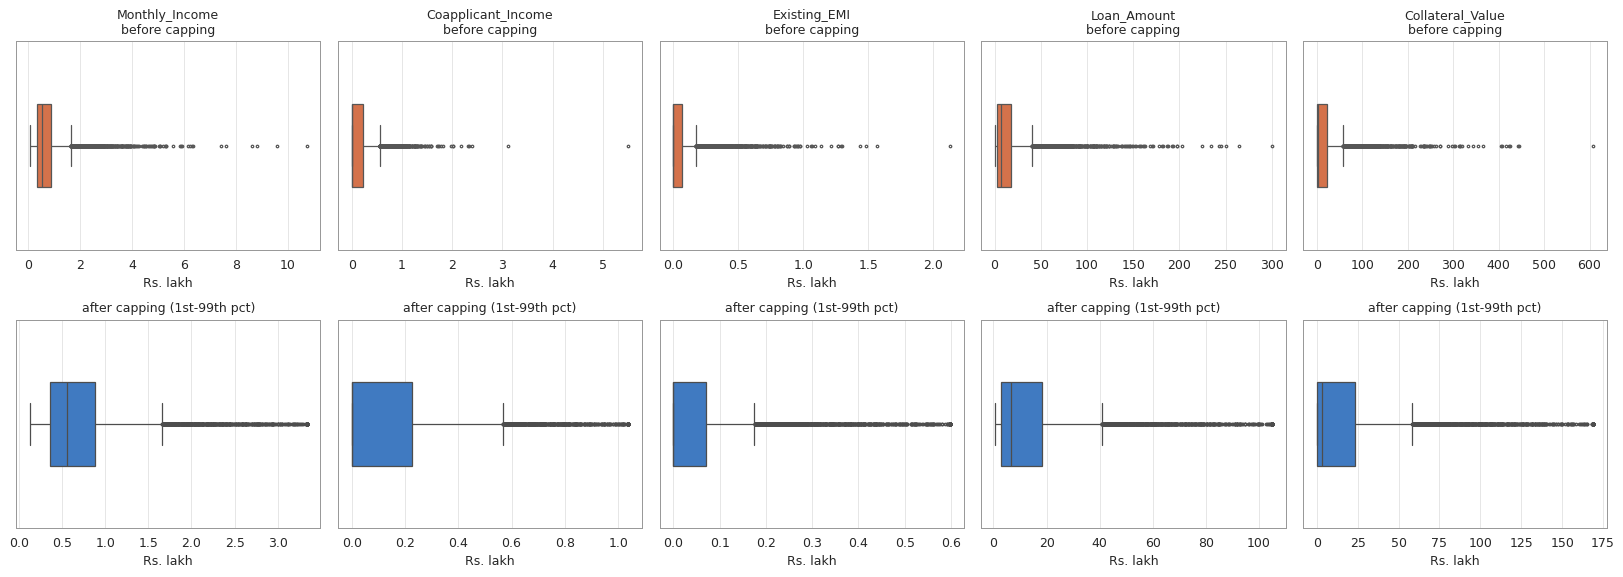

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6.5))
for i, col in enumerate(money_cols):
    # values shown in lakh (1 lakh = Rs. 1,00,000) so the axis numbers are short
    sns.boxplot(x=before_capping[col] / 100000, ax=axes[0, i], color=SECOND_COLOR, width=0.4, flierprops={'markersize': 2})
    axes[0, i].set_title(col + '\nbefore capping', fontsize=10)
    axes[0, i].set_xlabel('Rs. lakh')
    sns.boxplot(x=model_df[col] / 100000, ax=axes[1, i], color=MAIN_COLOR, width=0.4, flierprops={'markersize': 2})
    axes[1, i].set_title('after capping (1st-99th pct)', fontsize=10)
    axes[1, i].set_xlabel('Rs. lakh')
save_plot('p3_outlier_capping.png')

**Result of outlier treatment:**
- Only the 5 money columns were capped. Values changed: Monthly_Income 192, Coapplicant_Income 98, Existing_EMI 98, Loan_Amount 164, Collateral_Value 99. **No row was deleted.**
- Examples: Monthly_Income now runs from ₹12,700 to ₹3,33,480 (before: ₹8,000 to ₹10,72,200), and Loan_Amount from ₹60,000 to about ₹1.05 crore (before: up to ₹3 crore).
- Dots still appear after capping. That is expected: capping cuts only the extreme 1% at each end, and the IQR rule still marks the long right tail. The **log1p step (C3)** fixes the shape.
- Capping is only in the model copy. The real-unit file still has the true values, which the rule engine needs (for example, the ₹15,000 minimum-income check).

### C3. Transform skewed columns (P17)
**Rule:** if a column's skewness is **above 1** and it has no negative values, apply `log1p` (log of 1 + x). The `+1` lets zeros stay 0.
The skewness is measured **after** capping.

In [21]:
skew_table = []
log_cols = []
for col in numeric_cols:
    skew_before = model_df[col].skew()
    if skew_before > 1 and model_df[col].min() >= 0:
        log_cols.append(col)
    skew_table.append({'column': col, 'skew_before': round(skew_before, 2)})

print('Columns that get log1p:', log_cols)
transform_example = model_df['Monthly_Income'].copy()     # kept only for the example plot below

for col in log_cols:
    model_df[col] = np.log1p(model_df[col])
    add_log('P17', col + ' log1p transform', len(model_df), len(model_df))

for row in skew_table:
    row['log1p_applied'] = row['column'] in log_cols
    row['skew_after'] = round(model_df[row['column']].skew(), 2)
skew_table = pd.DataFrame(skew_table)
skew_table

Columns that get log1p: ['Monthly_Income', 'Coapplicant_Income', 'Existing_EMI', 'Loan_Amount', 'Loan_Tenure', 'Collateral_Value']
Monthly_Income log1p transform -> 9847 | rows now: 9847
Coapplicant_Income log1p transform -> 9847 | rows now: 9847
Existing_EMI log1p transform -> 9847 | rows now: 9847
Loan_Amount log1p transform -> 9847 | rows now: 9847
Loan_Tenure log1p transform -> 9847 | rows now: 9847
Collateral_Value log1p transform -> 9847 | rows now: 9847


,column,skew_before,log1p_applied,skew_after
0,Age,0.34,False,0.34
1,Dependents,0.15,False,0.15
2,Work_Experience,0.47,False,0.47
3,Monthly_Income,2.20,True,0.25
4,Coapplicant_Income,1.89,True,0.78
5,Existing_EMI,2.67,True,0.58
6,CIBIL_Score,-0.45,False,-0.45
7,Loan_Amount,2.47,True,0.09
8,Loan_Tenure,1.34,True,0.30
9,Collateral_Value,2.52,True,-0.32


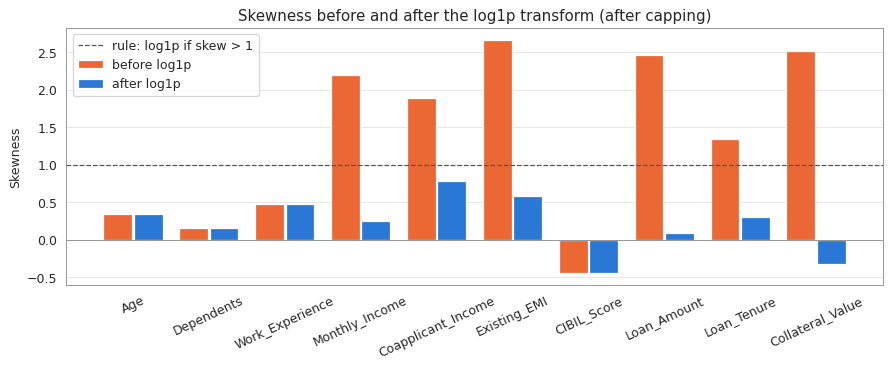

In [22]:
plt.figure(figsize=(10, 4.2))
x = np.arange(len(skew_table))
plt.bar(x - 0.2, skew_table['skew_before'], width=0.38, color=SECOND_COLOR, label='before log1p')
plt.bar(x + 0.2, skew_table['skew_after'], width=0.38, color=MAIN_COLOR, label='after log1p')
plt.axhline(1, color='#555555', linestyle='--', linewidth=1, label='rule: log1p if skew > 1')
plt.axhline(0, color='#999999', linewidth=0.8)
plt.xticks(x, skew_table['column'], rotation=25)
plt.ylabel('Skewness')
plt.title('Skewness before and after the log1p transform (after capping)')
plt.legend()
plt.gca().xaxis.grid(False)
save_plot('p3_skewness_before_after.png')

**Result of the log1p transform:** Six columns had skewness above 1 and were transformed:

| Column | Skewness before → after |
|---|---|
| Monthly_Income | 2.20 → 0.25 |
| Coapplicant_Income | 1.89 → 0.78 |
| Existing_EMI | 2.67 → 0.58 |
| Loan_Amount | 2.47 → 0.09 |
| Collateral_Value | 2.52 → −0.32 |
| Loan_Tenure | 1.34 → 0.30 |

- Age, Dependents, Work_Experience and CIBIL_Score were already close to symmetric (|skew| < 0.5), so they were not changed.
- Coapplicant_Income and Existing_EMI still have a big group at 0 (no co-applicant / no existing loan). That is real information, not a problem.

### C4. Encoding categorical columns

| Column | Encoding | Reason |
|---|---|---|
| Loan_Status | Already 1 / 0 (A5) | Target |
| Employment_Type | One-hot, reference = **Salaried** → `emp_sep`, `emp_senp` | No order between job types |
| Loan_Type | One-hot, reference = **Personal** → `loan_type_home`, `loan_type_vehicle`, `loan_type_business` | No order between loan types |
| Property_Area | Ordinal: Rural = 0, Semi-Urban = 1, Urban = 2 | There is a natural order (level of urbanisation) |
| Gender | One-hot, reference = **Male** | Protected: **audit only**, Phase 4 must not use it as a model input |
| Marital_Status | One-hot, reference = **Married** | Protected: **audit only** |
| Dependents | Already a number 0–3 (A5) | Count |

One reference level is dropped from each one-hot group (if all are 0, it is the reference). This avoids the "dummy variable trap" for linear models.

In [23]:
encoding = {
    'Employment_Type': {'reference': 'Salaried', 'columns': {'SEP': 'emp_sep', 'SENP': 'emp_senp'}},
    'Loan_Type': {'reference': 'Personal', 'columns': {'Home': 'loan_type_home', 'Vehicle': 'loan_type_vehicle',
                                                       'Business': 'loan_type_business'}},
    'Gender': {'reference': 'Male', 'columns': {'Female': 'gender_female', 'Transgender': 'gender_transgender',
                                                'Unknown': 'gender_unknown'}},
    'Marital_Status': {'reference': 'Married', 'columns': {'Single': 'marital_single', 'Divorced': 'marital_divorced',
                                                           'Widowed': 'marital_widowed', 'Unknown': 'marital_unknown'}},
}

for col in encoding:
    for category in encoding[col]['columns']:
        new_col = encoding[col]['columns'][category]
        model_df[new_col] = (model_df[col] == category).astype(int)
    print(col, '->', list(encoding[col]['columns'].values()), '(reference:', encoding[col]['reference'] + ')')
    model_df = model_df.drop(columns=col)

area_order = {'Rural': 0, 'Semi-Urban': 1, 'Urban': 2}
model_df['Property_Area'] = model_df['Property_Area'].map(area_order)
print('Property_Area ->', area_order)
add_log('-', 'Categorical columns encoded (4 one-hot groups + 1 ordinal)', 5, len(model_df))

Employment_Type -> ['emp_sep', 'emp_senp'] (reference: Salaried)
Loan_Type -> ['loan_type_home', 'loan_type_vehicle', 'loan_type_business'] (reference: Personal)
Gender -> ['gender_female', 'gender_transgender', 'gender_unknown'] (reference: Male)
Marital_Status -> ['marital_single', 'marital_divorced', 'marital_widowed', 'marital_unknown'] (reference: Married)
Property_Area -> {'Rural': 0, 'Semi-Urban': 1, 'Urban': 2}
Categorical columns encoded (4 one-hot groups + 1 ordinal) -> 5 | rows now: 9847


### C5. Scaling
We use `StandardScaler` (value − mean) ÷ standard deviation on every numeric column with **more than 3 different values**.
Binary 0/1 columns and the 0–2 ordinal `Property_Area` are left as they are.

In [24]:
scale_cols = []
for col in numeric_cols:
    if model_df[col].nunique() > 3:
        scale_cols.append(col)
print('Columns to scale:', scale_cols)

scaler = StandardScaler()
model_df[scale_cols] = scaler.fit_transform(model_df[scale_cols])
add_log('-', 'StandardScaler on numeric columns', len(scale_cols), len(model_df))

scaler_params = {}
for i, col in enumerate(scale_cols):
    scaler_params[col] = {'mean': float(scaler.mean_[i]), 'std': float(scaler.scale_[i]), 'log1p': col in log_cols}

check = model_df[scale_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)
check

Columns to scale: ['Age', 'Dependents', 'Work_Experience', 'Monthly_Income', 'Coapplicant_Income', 'Existing_EMI', 'CIBIL_Score', 'Loan_Amount', 'Loan_Tenure', 'Collateral_Value']
StandardScaler on numeric columns -> 10 | rows now: 9847


,mean,std,min,max
Age,0.0,1.0,-2.007,3.736
Dependents,0.0,1.0,-1.257,1.527
Work_Experience,-0.0,1.0,-1.612,4.395
Monthly_Income,-0.0,1.0,-2.221,2.610
Coapplicant_Income,-0.0,1.0,-0.686,1.671
Existing_EMI,-0.0,1.0,-0.763,1.680
CIBIL_Score,0.0,1.0,-4.710,2.603
Loan_Amount,0.0,1.0,-2.040,2.205
Loan_Tenure,-0.0,1.0,-1.864,1.998
Collateral_Value,-0.0,1.0,-1.201,1.161


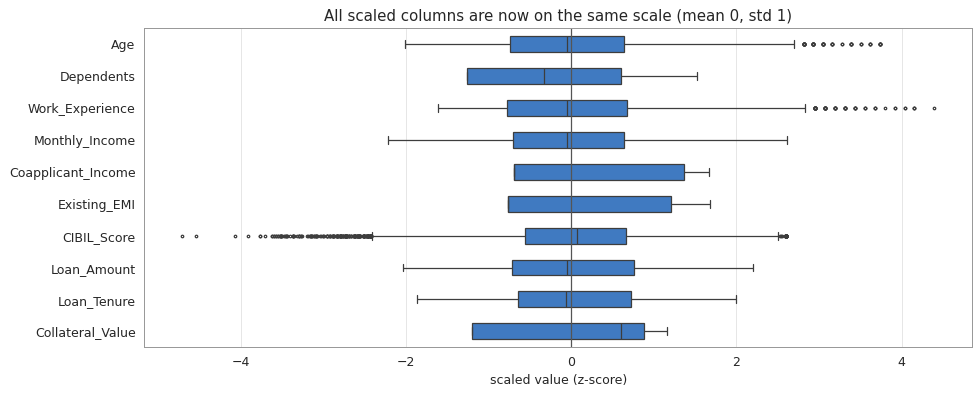

In [25]:
plt.figure(figsize=(11, 4.5))
sns.boxplot(data=model_df[scale_cols], orient='h', color=MAIN_COLOR, width=0.5, flierprops={'markersize': 2})
plt.axvline(0, color='#555555', linewidth=1)
plt.title('All scaled columns are now on the same scale (mean 0, std 1)')
plt.xlabel('scaled value (z-score)')
save_plot('p3_scaled_columns.png')

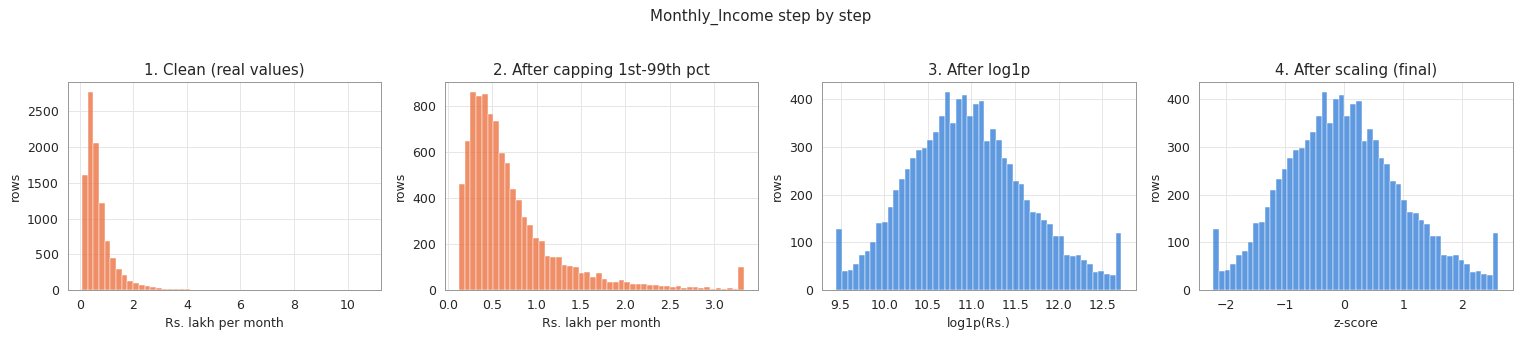

In [26]:
# one example column through every step
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
sns.histplot(before_capping['Monthly_Income'] / 100000, bins=50, color=SECOND_COLOR, ax=axes[0])
axes[0].set_title('1. Clean (real values)')
axes[0].set_xlabel('Rs. lakh per month')
sns.histplot(transform_example / 100000, bins=50, color=SECOND_COLOR, ax=axes[1])
axes[1].set_title('2. After capping 1st-99th pct')
axes[1].set_xlabel('Rs. lakh per month')
sns.histplot(np.log1p(transform_example), bins=50, color=MAIN_COLOR, ax=axes[2])
axes[2].set_title('3. After log1p')
axes[2].set_xlabel('log1p(Rs.)')
sns.histplot(model_df['Monthly_Income'], bins=50, color=MAIN_COLOR, ax=axes[3])
axes[3].set_title('4. After scaling (final)')
axes[3].set_xlabel('z-score')
for ax in axes:
    ax.set_ylabel('rows')
plt.suptitle('Monthly_Income step by step', y=1.03)
save_plot('p3_transform_example_income.png')

**Result of encoding and scaling:**
- 4 one-hot groups (12 new 0/1 columns) plus 1 ordinal column (Property_Area 0/1/2).
- 10 numeric columns were scaled. Every scaled column now has **mean 0 and std 1** (see the table above).
- The scaler's mean and std are saved, so any scaled value can be turned back into real units for explanations. Example for Monthly_Income: Rs. = exp(z × 0.6764 + 10.9517) − 1.
- The Monthly_Income example shows the full path: very skewed rupees → capped → bell shape after log1p → same shape centred at 0 after scaling. The small bars at both ends are the capped values.

### C6. Rename, order and save the semi-preprocessed dataset

In [27]:
rename_map = {
    'Loan_ID': 'loan_id', 'Age': 'age', 'Dependents': 'dependents', 'Work_Experience': 'work_experience',
    'Monthly_Income': 'monthly_income', 'Coapplicant_Income': 'coapplicant_income', 'Existing_EMI': 'existing_emi',
    'CIBIL_Score': 'cibil_score', 'Loan_Amount': 'loan_amount', 'Loan_Tenure': 'loan_tenure_months',
    'Collateral_Value': 'collateral_value', 'Property_Area': 'property_area', 'Loan_Status': 'loan_status',
}
model_df = model_df.rename(columns=rename_map)

column_order = ['loan_id', 'age', 'dependents', 'work_experience', 'monthly_income', 'coapplicant_income',
                'existing_emi', 'cibil_score', 'is_new_to_credit', 'loan_amount', 'loan_tenure_months',
                'collateral_value', 'property_area',
                'emp_sep', 'emp_senp', 'loan_type_home', 'loan_type_vehicle', 'loan_type_business',
                'gender_female', 'gender_transgender', 'gender_unknown',
                'marital_single', 'marital_divorced', 'marital_widowed', 'marital_unknown',
                'loan_status']
semi_df = model_df[column_order].copy()

float_cols = semi_df.select_dtypes(include='float').columns
semi_df[float_cols] = semi_df[float_cols].round(6)

semi_path = os.path.join(OUT_DIR, 'semi_preprocessed_dataset.csv')
semi_df.to_csv(semi_path, index=False)
print('Saved:', semi_path, semi_df.shape)
print('Missing values:', semi_df.isnull().sum().sum())
print('Text columns:', list(semi_df.select_dtypes(exclude='number').columns))
semi_df.head()

Saved: ../data/processed/semi_preprocessed_dataset.csv (9847, 26)
Missing values: 0
Text columns: ['loan_id']


,loan_id,age,dependents,work_experience,monthly_income,coapplicant_income,existing_emi,cibil_score,is_new_to_credit,loan_amount,loan_tenure_months,collateral_value,property_area,emp_sep,emp_senp,loan_type_home,loan_type_vehicle,loan_type_business,gender_female,gender_transgender,gender_unknown,marital_single,marital_divorced,marital_widowed,marital_unknown,loan_status
0,LN2025102971,0.289984,-1.257268,0.550569,-0.324747,-0.686312,0.913641,1.358259,0,0.573094,1.528950,0.863300,0,0,0,1,0,0,0,1,0,0,0,0,0,1
1,LN2025107793,0.979155,0.599130,0.670701,-0.585281,-0.686312,-0.763414,0.207723,0,-0.773580,-0.648286,-1.201138,1,0,1,0,0,0,0,0,0,0,0,0,0,1
2,LN2025102488,-1.547807,-1.257268,-1.131284,-0.547274,1.368390,-0.763414,1.831082,0,1.086974,1.528950,0.945417,0,0,0,1,0,0,0,0,0,1,0,0,0,1
3,LN2025106297,-0.399188,-1.257268,-0.410490,-0.165757,-0.686312,-0.763414,0.191962,0,0.914104,1.528950,0.912406,2,0,1,1,0,0,0,0,0,0,0,0,0,1
4,LN2025108470,-1.662669,-1.257268,-1.611813,-0.400919,-0.686312,-0.763414,1.043044,0,-0.365340,-0.648286,-1.201138,1,0,0,0,0,0,0,0,0,1,0,0,0,0


### C7. Save every value we used (`transform_params.json`)

In [28]:
params = {
    'note': 'All values were calculated on the 9,847 cleaned rows (Phase 3).',
    'category_map': clean_map,
    'imputation_values': imputation_values,
    'cibil_ntc_replacement': int(cibil_median),
    'capping_1st_99th_percentile': cap_values,
    'log1p_columns': log_cols,
    'scaler': scaler_params,
    'encoding_one_hot': encoding,
    'encoding_ordinal': {'Property_Area': area_order},
    'renamed_columns': rename_map,
}


def to_plain(value):
    # json cannot save numpy numbers, so change them into normal Python numbers
    if isinstance(value, dict):
        new_dict = {}
        for key in value:
            new_dict[str(key)] = to_plain(value[key])
        return new_dict
    if isinstance(value, list):
        return [to_plain(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


with open('transform_params.json', 'w') as f:
    json.dump(to_plain(params), f, indent=2)
print('Saved: phase3/transform_params.json')
print('Example - to get Monthly_Income back in Rs.:  Rs. = exp(z * std + mean) - 1')
print(scaler_params['Monthly_Income'])

Saved: phase3/transform_params.json
Example - to get Monthly_Income back in Rs.:  Rs. = exp(z * std + mean) - 1
{'mean': 10.951716392336568, 'std': 0.6763887768507639, 'log1p': True}


## Part D: Summary and checks

In [29]:
log_table = pd.DataFrame(cleaning_log)
log_table

,issue,step,count,rows_after_step
0,P03,Extra spaces removed (cells),991,10000
1,P01,Exact duplicate rows removed,135,9865
2,P02,Rows without Loan_Status removed,18,9847
3,P03,Badly spelled category cells fixed,3904,9847
4,P04,Loan_Amount text values converted to numbers,578,9847
5,P05,"Dependents ""3+"" changed to 3",1819,9847
6,P07,Impossible Age set to missing,28,9847
7,P09,Negative Monthly_Income made positive,22,9847
8,P10,Zero Monthly_Income set to missing,8,9847
9,P11,Invalid CIBIL_Score set to missing,32,9847


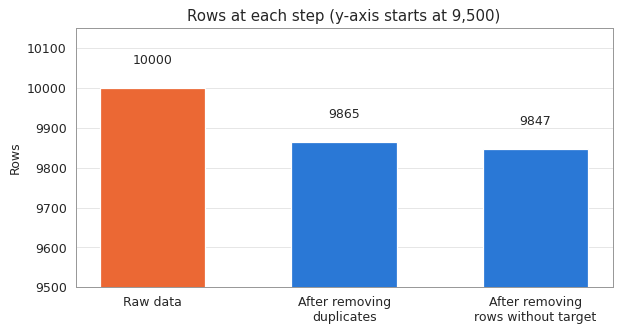

In [30]:
steps = ['Raw data', 'After removing\nduplicates', 'After removing\nrows without target']
rows = [len(raw), len(raw) - n_duplicates, len(clean_df)]
plt.figure(figsize=(7, 3.8))
bars = plt.bar(steps, rows, color=[SECOND_COLOR, MAIN_COLOR, MAIN_COLOR], width=0.55)
for bar, value in zip(bars, rows):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 60, str(value), ha='center', fontsize=10)
plt.ylim(9500, 10150)
plt.ylabel('Rows')
plt.title('Rows at each step (y-axis starts at 9,500)')
plt.gca().xaxis.grid(False)
save_plot('p3_row_flow.png')

In [31]:
print('Raw dataset                       :', raw.shape)
print('cleaned_dataset_original_units.csv:', clean_df.shape, '| missing:', clean_df.isnull().sum().sum())
print('semi_preprocessed_dataset.csv     :', semi_df.shape, '| missing:', semi_df.isnull().sum().sum())
print('Same Loan_IDs in both files       :', (clean_df['Loan_ID'].values == semi_df['loan_id'].values).all())
print('Loan_ID unique                    :', semi_df['loan_id'].is_unique)
print('Approval rate (%)                 :', round(semi_df['loan_status'].mean() * 100, 2))
print('Raw file was not changed          :', raw.equals(pd.read_csv(RAW_PATH)))

Raw dataset                       : (10000, 17)
cleaned_dataset_original_units.csv: (9847, 17) | missing: 0
semi_preprocessed_dataset.csv     : (9847, 26) | missing: 0
Same Loan_IDs in both files       : True
Loan_ID unique                    : True
Approval rate (%)                 : 58.46
Raw file was not changed          : True


### Phase 3 summary

| Output | Shape | Missing | Notes |
|---|---|---|---|
| `data/processed/semi_preprocessed_dataset.csv` | 9,847 × 26 | 0 | Model-ready version of the 15 raw columns (+ `is_new_to_credit`) |
| `data/processed/cleaned_dataset_original_units.csv` | 9,847 × 17 | 0 | Same rows, real units, readable labels |
| `phase3/transform_params.json` | – | – | All medians, caps, scaler values and encodings |

- Both datasets have the **same 9,847 Loan_IDs in the same order**.
- The approval rate is 58.46%.
- The raw file was not changed.
- **Phase 4 should build its ratio features from `cleaned_dataset_original_units.csv`** and apply the same transform rules (cap → log1p if skew > 1 → scale) to them.